In [2]:
import os

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split
import torch
import torch.optim as optim

from PIL import Image
import numpy as np
from sklearn.metrics import confusion_matrix
import random
import math
import matplotlib.pyplot as plt
import seaborn as sns

RAND_SEED = 18
brats_dir_path = "../data/raw/brats_tif"
brats_metadata_path = "../data/raw/brats_tif/data.csv"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("NVIDIA Cuda available: ", torch.cuda.is_available())
print("GPU: ", torch.cuda.get_device_name(0)) 

NVIDIA Cuda available:  True
GPU:  NVIDIA GeForce GTX 1050 Ti


Tensor shape: torch.Size([3, 256, 256])


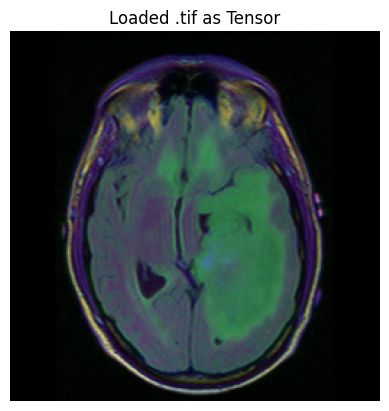

In [6]:
image = Image.open(brats_dir_path+"/TCGA_CS_5393_19990606/TCGA_CS_5393_19990606_10.tif").convert("RGB")

transform = transforms.ToTensor()
tensor_image = transform(image)

print(f"Tensor shape: {tensor_image.shape}")

def show_tensor_image(tensor):
    if tensor.shape[0] == 1:
        plt.imshow(tensor.squeeze(0), cmap="gray")
    else:
        plt.imshow(tensor.permute(1, 2, 0))
    plt.axis("off")
    plt.title("Loaded .tif as Tensor")
    plt.show()

show_tensor_image(tensor_image)

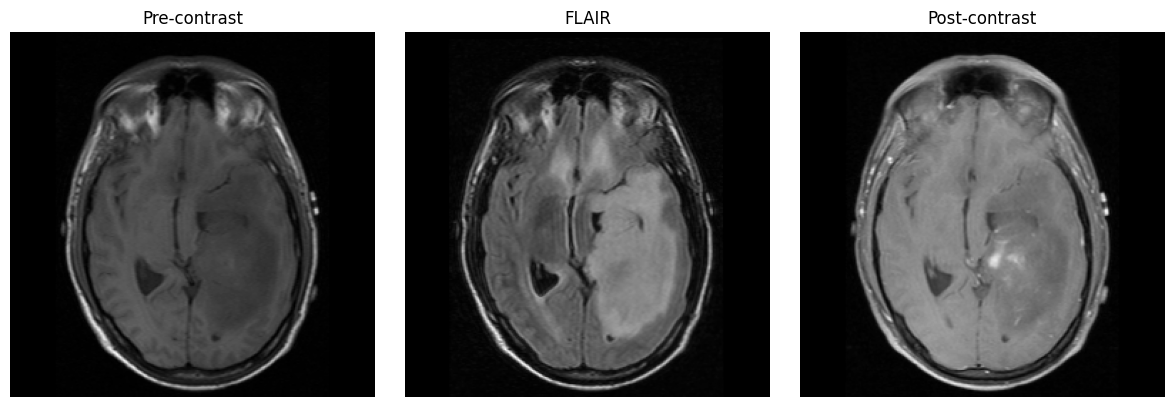

In [7]:
from PIL import Image
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Load .tif image (3 MRI sequences)
img = Image.open(brats_dir_path+"/TCGA_CS_5393_19990606/TCGA_CS_5393_19990606_10.tif")  # 3-channel .tif
img_tensor = transforms.ToTensor()(img)  # shape: (3, H, W)

# Visualize each sequence individually
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
sequence_names = ['Pre-contrast', 'FLAIR', 'Post-contrast']

for i in range(3):
    axs[i].imshow(img_tensor[i], cmap='gray')
    axs[i].set_title(sequence_names[i])
    axs[i].axis('off')

plt.tight_layout()
plt.show()
